# Point statistics

The `ps` (point statistics) module provides metrics to compare the mean spatial distribution of transcripts in relation to the centroid and the segmented outline of the cell. The idea of this module is to provide an intuition whether transcripts are distributed unequally, meaning they are more likely to have resulted from a spillover from neighbouring cells. The computed values can either be returned as a dictionary or stored in place in the `spatialdata` object.

**NOTE:** these metrics are still under active development and will change in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Run the two metrics one at a time

In [36]:
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

# Load spatial transcriptomics dataset and initalize SegTraQ object
sdata = sd.read_zarr("../../../data/xenium.zarr")
# only looking at a subset for visualization purposes
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h
sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)
st = segtraq.SegTraQ(sdata, images_key="image")

version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/emartin/.venv/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/emartin/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/home/emartin/SegTraQ/src/segtraq/SegTraQ.py:120: UserWarning: Missing 8 cell IDs in tables: ['apnfcbpf-1', 'icefbjdk-1', 'aphffbmb-1', 'iceeeemj-1', 'iceelejf-1']... These cells are present in shapes, but not in tables. This might lead to inconsistencies in the spatialdata object.
  validate_spatialdata(


The first metric we compute is the comparison of the centroid coordinate with the mean coordinate of the transcripts. This metric runs per transcript ID, which has to be passed to the function. We compute the euclidean distance between the mean coordinate per transcript $\mu_{x,y}$ with the cell centroid coordinate $cc_{x,y}$ normalised by the cell area $|C|$. The normalisation by cell area is necessary because the computed euclidean distance scales with the cell area.

$$
d_{centroid-mean} = \frac{\sqrt{cc_{x,y}^2-\mu_{x,y}^2}}{|C|}
$$

In [38]:
st.ps.centroid_mean_coord_diff("ERBB2", inplace=True)

,cell_id,centroid_x,x,centroid_y,y,distance,cell_area,distance_ERBB2
0,apheleok-1,985.778158,985.089111,1191.758907,1192.134766,292.053855,43.666095,6.688344
1,aphidfcb-1,847.440346,846.534424,1204.523379,1199.822266,502.323709,45.020783,11.157596
2,aphjeaih-1,896.008961,896.242737,1176.362067,1175.994141,396.053709,144.409693,2.742570
3,aphjibjb-1,902.717059,903.323486,1185.087632,1185.001953,398.843071,162.562506,2.453475
4,aphjipcp-1,906.175978,907.237549,1173.395138,1175.572266,378.700703,83.539066,4.533217
...,...,...,...,...,...,...,...,...
72,ipocgjja-1,914.824386,910.706299,1191.846922,1193.259766,395.684610,102.007972,3.878958
73,ipocjkfn-1,949.063130,952.190674,1154.533621,1152.166016,286.694002,101.059691,2.836878
74,ipoclfbi-1,967.669438,968.940674,1150.176639,1151.947266,258.466231,98.124535,2.634063
75,jaadeldi-1,927.709138,927.526611,1357.700496,1353.712891,605.416194,137.455630,4.404448


This result is also stored in `spatialdata` object and accesible in the observations of the `anndata` component.

In [39]:
sdata["table"].obs[sdata["table"].obs["distance_ERBB2"].notna()].head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,segmentation_method,label_id,region,centroid_x,x,centroid_y,y,distance,cell_area,distance_ERBB2
3803,apheleok-1,985.953428,1191.931367,121,0,0,0,0,21,142,...,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3804,cell_labels,985.778158,985.089111,1191.758907,1192.134766,292.053855,43.666095,6.688344
3845,aphidfcb-1,847.619199,1204.688203,99,0,1,0,0,27,127,...,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3846,cell_labels,847.440346,846.534424,1204.523379,1199.822266,502.323709,45.020783,11.157596
3851,aphjeaih-1,896.131162,1176.530000,452,0,0,0,0,106,558,...,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3852,cell_labels,896.008961,896.242737,1176.362067,1175.994141,396.053709,144.409693,2.742570
3855,aphjibjb-1,902.833555,1185.372773,440,0,0,0,0,78,518,...,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3856,cell_labels,902.717059,903.323486,1185.087632,1185.001953,398.843071,162.562506,2.453475
3856,aphjipcp-1,906.314512,1173.572969,265,0,0,0,0,44,309,...,Segmented by boundary stain (ATP1A1+CD45+E-Cad...,3857,cell_labels,906.175978,907.237549,1173.395138,1175.572266,378.700703,83.539066,4.533217


We can visualise these results in space for the gene ERBB2

In [40]:
gene_name = "ERBB2"

In [41]:
import copy

sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_ERBB2"].notna()]

/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


In [42]:
# link annotations with cell boundaries
sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries")

/tmp/ipykernel_2341/3780718550.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/emartin/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/emartin/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(

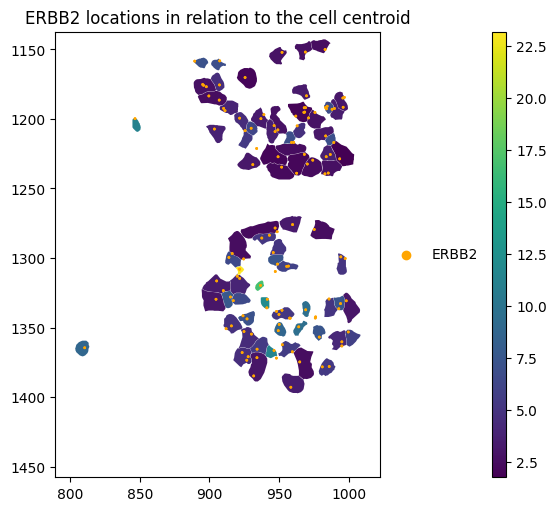

In [50]:
sdata_plot.pl.render_shapes(
    "cell_boundaries",
    color="distance_ERBB2",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name,
    palette="orange",
).pl.show(
    title=f"{gene_name} locations in relation to the cell centroid",
    coordinate_systems="global",
    figsize=(10, 5),
)

We notice that there are some cells with a lot of cells at the boundary and some others that are more balanced

The other metric implemented on the transcript coordinate level is the comparison of the transcript locations in relation to the distance to the membrane. In some sense, this is complementary to the `centroid_mean_coord_diff` metric. However, in the case of very irregularly shaped cells, the distance to the membrane is a more direct measure of unequal transcript distribution and hence potential spillover.  

The metric is defined as the mean distance to the cell membrane $\mu(d(m,t))$ (as provided in the `spatialdata` object) divided by the cell area $|C|$.

$$
d_{membrane} = \frac{\mu(d(m,t))}{|C|}
$$

In [46]:
st.ps.distance_to_membrane("ERBB2")

,cell_id,distance_to_outline_ERBB2,cell_area,distance_to_outline_inverse_ERBB2
0,apheleok-1,1.002028,43.666095,0.998988
1,aphidfcb-1,0.046875,45.020783,4.618802
2,aphjeaih-1,4.259394,144.409693,0.484536
3,aphjibjb-1,3.361656,162.562506,0.545410
4,aphjipcp-1,3.252922,83.539066,0.554451
...,...,...,...,...
72,ipocgjja-1,1.651899,102.007972,0.778051
73,ipocjkfn-1,1.841699,101.059691,0.736870
74,ipoclfbi-1,1.104993,98.124535,0.951306
75,jaadeldi-1,1.513872,137.455630,0.812747


Also this result is also stored in spatialdata object and accesible in the observations of the anndata component.

In [47]:
sdata["table"].obs[
    sdata["table"].obs["distance_to_outline_ERBB2"].notna()
    | sdata["table"].obs["distance_to_outline_inverse_ERBB2"].notna()
]

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,region,centroid_x,x,centroid_y,y,distance,cell_area,distance_ERBB2,distance_to_outline_ERBB2,distance_to_outline_inverse_ERBB2
3803,apheleok-1,985.953428,1191.931367,121,0,0,0,0,21,142,...,cell_labels,985.778158,985.089111,1191.758907,1192.134766,292.053855,43.666095,6.688344,1.002028,0.998988
3845,aphidfcb-1,847.619199,1204.688203,99,0,1,0,0,27,127,...,cell_labels,847.440346,846.534424,1204.523379,1199.822266,502.323709,45.020783,11.157596,0.046875,4.618802
3851,aphjeaih-1,896.131162,1176.530000,452,0,0,0,0,106,558,...,cell_labels,896.008961,896.242737,1176.362067,1175.994141,396.053709,144.409693,2.742570,4.259394,0.484536
3855,aphjibjb-1,902.833555,1185.372773,440,0,0,0,0,78,518,...,cell_labels,902.717059,903.323486,1185.087632,1185.001953,398.843071,162.562506,2.453475,3.361656,0.545410
3856,aphjipcp-1,906.314512,1173.572969,265,0,0,0,0,44,309,...,cell_labels,906.175978,907.237549,1173.395138,1175.572266,378.700703,83.539066,4.533217,3.252922,0.554451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15354,ipocgjja-1,914.939512,1191.996797,285,0,0,0,0,46,331,...,cell_labels,914.824386,910.706299,1191.846922,1193.259766,395.684610,102.007972,3.878958,1.651899,0.778051
15357,ipocjkfn-1,949.197324,1154.718477,282,0,0,0,0,66,348,...,cell_labels,949.063130,952.190674,1154.533621,1152.166016,286.694002,101.059691,2.836878,1.841699,0.736870
15358,ipoclfbi-1,967.801328,1150.317109,254,0,0,0,0,46,300,...,cell_labels,967.669438,968.940674,1150.176639,1151.947266,258.466231,98.124535,2.634063,1.104993,0.951306
15762,jaadeldi-1,927.810605,1357.838594,406,0,0,0,0,46,452,...,cell_labels,927.709138,927.526611,1357.700496,1353.712891,605.416194,137.455630,4.404448,1.513872,0.812747


We can plot the metrics in space

In [48]:
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_to_outline_inverse_ERBB2"].notna()]

# link annotations with cell boundaries
sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries")

/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/tmp/ipykernel_2341/229737362.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/emartin/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/emartin/.local/share/uv/python/cpython-3.13.5-linux-x86_64-gnu/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/emartin/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(

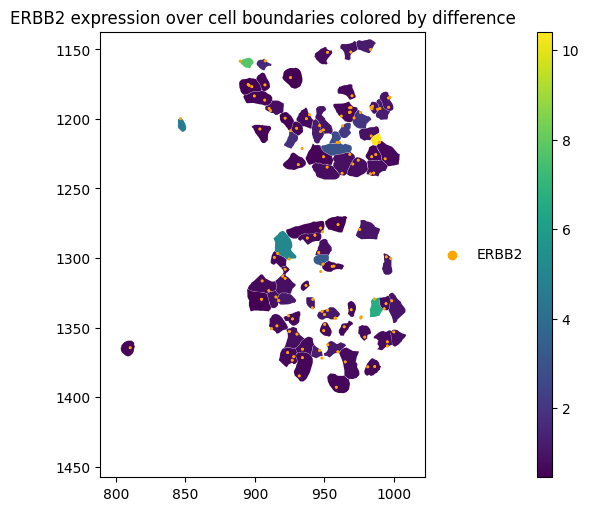

In [49]:
sdata_plot.pl.render_shapes(
    "cell_boundaries",
    color="distance_to_outline_inverse_ERBB2",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name,
    palette="orange",
).pl.show(
    title=f"{gene_name} locations in relation to the cell membrane",
    coordinate_systems="global",
    figsize=(10, 5),
)

We note that the two metrics are complementary to each other. However, there are situations with irregularly shaped cells where the distance to the centroid might be very small although the transcripts are clearly on the boarder of the cell.